In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Using device: {device}")

class ManualBatchNorm(nn.Module):
    """BatchNorm for 2D input (batch, features)."""
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super().__init__()
        self.eps      = eps
        self.momentum = momentum
        # Learnable scale and shift
        self.gamma    = nn.Parameter(torch.ones(num_features))
        self.beta     = nn.Parameter(torch.zeros(num_features))
        # Running stats for inference (not learned — updated via momentum), required when the sequence length is not the same across batches
        self.register_buffer('running_mean', torch.zeros(num_features))
        self.register_buffer('running_var',  torch.ones(num_features))

    def forward(self, x):
        # x: (batch, features)
        if self.training:
            mean = x.mean(dim=0)              # across batch dim=0
            var  = x.var(dim=0, unbiased=False)
            # Update running stats for inference
            self.running_mean = (1 - self.momentum) * self.running_mean \
                                + self.momentum * mean.detach()
            self.running_var  = (1 - self.momentum) * self.running_var  \
                                + self.momentum * var.detach()
        else:
            mean = self.running_mean
            var  = self.running_var

        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_norm + self.beta

class ManualLayerNorm(nn.Module):
    """LayerNorm for input of any shape — normalizes last dimension."""
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        self.eps   = eps
        self.gamma = nn.Parameter(torch.ones(normalized_shape))
        self.beta  = nn.Parameter(torch.zeros(normalized_shape))

    def forward(self, x):
        # Normalize across last dimension (features) per sample dim =-1
        mean  = x.mean(dim=-1, keepdim=True)
        var   = x.var(dim=-1, keepdim=True, unbiased=False)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_norm + self.beta


print("── Verifying Manual Implementations ───────────────")
torch.manual_seed(42)

x_test = torch.randn(8, 16)   # (batch=8, features=16)

# BatchNorm comparison
my_bn  = ManualBatchNorm(16)
pt_bn  = nn.BatchNorm1d(16)
# Match initial weights
pt_bn.weight.data = my_bn.gamma.data.clone()
pt_bn.bias.data   = my_bn.beta.data.clone()

out_my = my_bn(x_test)
out_pt = pt_bn(x_test)
print(f"BatchNorm max diff vs PyTorch: {(out_my - out_pt).abs().max():.6f}")

my_ln  = ManualLayerNorm(16)
pt_ln  = nn.LayerNorm(16)
pt_ln.weight.data = my_ln.gamma.data.clone()
pt_ln.bias.data   = my_ln.beta.data.clone()

out_my = my_ln(x_test)
out_pt = pt_ln(x_test)
print(f"LayerNorm max diff vs PyTorch: {(out_my - out_pt).abs().max():.6f}")

print("\n── Normalization Dimension Demo ────────────────────")

# Simulating a (batch=4, seq_len=6, features=8) tensor
# as you'd see in a Transformer
x_3d = torch.randn(4, 6, 8)

# BatchNorm1d needs (batch, features, seq) — note the transpose
bn   = nn.BatchNorm1d(8)
x_bn = bn(x_3d.transpose(1, 2)).transpose(1, 2)         # Here you are swapping dim 1 and 2 

# LayerNorm operates on last dim naturally
ln   = nn.LayerNorm(8)
x_ln = ln(x_3d)

print(f"Input shape:         {x_3d.shape}")
print(f"After BatchNorm:     {x_bn.shape}")
print(f"After LayerNorm:     {x_ln.shape}")

# Show that LayerNorm normalizes per token
print(f"\nLayerNorm — per-token mean (should be ~0):")
for i in range(3):
    token_mean = x_ln[0, i, :].mean().item()
    token_std  = x_ln[0, i, :].std().item()
    print(f"  Token {i}: mean={token_mean:.4f}, std={token_std:.4f}")

print(f"\nBatchNorm — per-feature mean across batch (should be ~0):")
for j in range(3):
    feat_mean = x_bn[:, :, j].mean().item()
    print(f"  Feature {j}: mean={feat_mean:.4f}")


Using device: mps
── Verifying Manual Implementations ───────────────
BatchNorm max diff vs PyTorch: 0.000000
LayerNorm max diff vs PyTorch: 0.000000

── Normalization Dimension Demo ────────────────────
Input shape:         torch.Size([4, 6, 8])
After BatchNorm:     torch.Size([4, 6, 8])
After LayerNorm:     torch.Size([4, 6, 8])

LayerNorm — per-token mean (should be ~0):
  Token 0: mean=0.0000, std=1.0690
  Token 1: mean=0.0000, std=1.0690
  Token 2: mean=0.0000, std=1.0690

BatchNorm — per-feature mean across batch (should be ~0):
  Feature 0: mean=-0.0000
  Feature 1: mean=-0.0000
  Feature 2: mean=0.0000


In [8]:
torch.manual_seed(0)
N = 2000
X = torch.randn(N, 20)
# Make it slightly non-trivial
y = ((X[:, 0] + X[:, 1] * 2 - X[:, 2] + torch.randn(N) * 0.5) > 0).long()

split  = int(0.8 * N)
X_tr, X_val_ = X[:split].to(device), X[split:].to(device)
y_tr, y_val_ = y[:split].to(device), y[split:].to(device)

# Declaring a normal MLP with a default flow between layers no custom forward required 
def make_model(norm_type, input_dim=20, hidden=128, num_layers=20):
    """Build a deep MLP with specified normalization."""
    layers = []
    in_dim = input_dim

    # where you append layers and if clause append based on what type of Norm
    for i in range(num_layers):
        layers.append(nn.Linear(in_dim, hidden))

        if norm_type == 'batch':
            layers.append(nn.BatchNorm1d(hidden))
        elif norm_type == 'layer':
            layers.append(nn.LayerNorm(hidden))
        # 'none' — no normalization layer added

        layers.append(nn.ReLU())
        in_dim = hidden

    layers.append(nn.Linear(hidden, 2))
    return nn.Sequential(*layers)

def train_and_eval(norm_type, epochs=40, lr=0.001, batch_size=64):
    model     = make_model(norm_type).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        perm       = torch.randperm(X_tr.shape[0])
        epoch_loss = 0
        n_batches  = 0

        for i in range(0, X_tr.shape[0], batch_size):
            idx     = perm[i:i + batch_size]
            xb, yb  = X_tr[idx], y_tr[idx]

            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches  += 1

        train_losses.append(epoch_loss / n_batches)

        # Validation accuracy
        model.eval()
        with torch.no_grad():
            preds    = model(X_val_).argmax(dim=1)
            val_acc  = (preds == y_val_).float().mean().item()
        val_accs.append(val_acc)

    return train_losses, val_accs

print("\nTraining three models (No Norm, BatchNorm, LayerNorm)...")

results = {}
for norm in ['none', 'batch', 'layer']:
    print(f"  Training with norm='{norm}'...")
    t_loss, v_acc = train_and_eval(norm, epochs=40)
    results[norm] = {'loss': t_loss, 'acc': v_acc}
    print(f"    Final val acc: {v_acc[-1]:.3f}")



Training three models (No Norm, BatchNorm, LayerNorm)...
  Training with norm='none'...
    Final val acc: 0.480
  Training with norm='batch'...
    Final val acc: 0.855
  Training with norm='layer'...
    Final val acc: 0.480


In [9]:
class PostLNBlock(nn.Module):
    """Original Transformer — LayerNorm after residual (Vaswani 2017)."""
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.ff   = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.ReLU(),
            nn.Linear(d_model * 4, d_model)
        )
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x + sublayer(x) first, then normalize
        return self.norm(x + self.dropout(self.ff(x)))          # Layer in concern 

class PreLNBlock(nn.Module):
    """Modern Transformer — LayerNorm before sublayer (GPT-2 style)."""
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.ff   = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.ReLU(),
            nn.Linear(d_model * 4, d_model)
        )
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Normalize first, then sublayer, then residual
        return x + self.dropout(self.ff(self.norm(x)))          # Layer in concern 

x_seq  = torch.randn(2, 10, 64)   # (batch, seq_len, d_model)
post   = PostLNBlock(64)
pre    = PreLNBlock(64)
print(f"\nPost-LN output shape: {post(x_seq).shape}")
print(f"Pre-LN  output shape: {pre(x_seq).shape}")
print("Both produce same shape — difference is training stability")



Post-LN output shape: torch.Size([2, 10, 64])
Pre-LN  output shape: torch.Size([2, 10, 64])
Both produce same shape — difference is training stability


/var/folders/3f/2_5h5tw15552syq1ng5v52h00000gn/T/ipykernel_6634/3509930417.py:76: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/3f/2_5h5tw15552syq1ng5v52h00000gn/T/ipykernel_6634/3509930417.py:76: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()


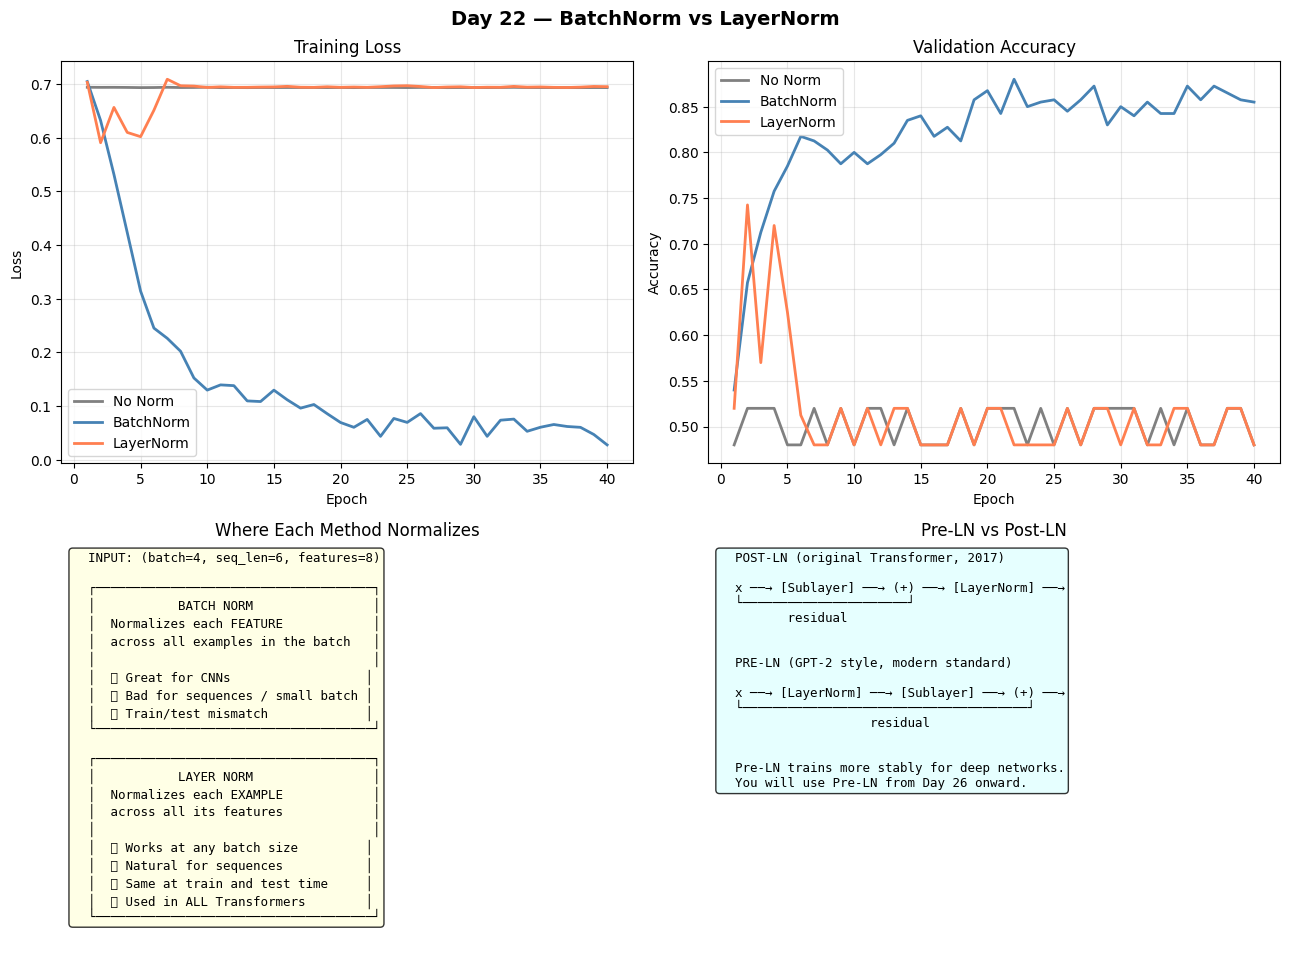

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Day 22 — BatchNorm vs LayerNorm', fontsize=14, fontweight='bold')

epochs_range = range(1, 41)
colors       = {'none': 'gray', 'batch': 'steelblue', 'layer': 'coral'}
labels       = {'none': 'No Norm', 'batch': 'BatchNorm', 'layer': 'LayerNorm'}

# Training loss
for norm, data in results.items():
    axes[0, 0].plot(epochs_range, data['loss'],
                    label=labels[norm], color=colors[norm], linewidth=2)
axes[0, 0].set_title('Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Validation accuracy
for norm, data in results.items():
    axes[0, 1].plot(epochs_range, data['acc'],
                    label=labels[norm], color=colors[norm], linewidth=2)
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].axis('off')
diagram = (
    "  INPUT: (batch=4, seq_len=6, features=8)\n\n"
    "  ┌─────────────────────────────────────┐\n"
    "  │           BATCH NORM                │\n"
    "  │  Normalizes each FEATURE            │\n"
    "  │  across all examples in the batch   │\n"
    "  │                                     │\n"
    "  │  ✅ Great for CNNs                  │\n"
    "  │  ❌ Bad for sequences / small batch │\n"
    "  │  ❌ Train/test mismatch             │\n"
    "  └─────────────────────────────────────┘\n\n"
    "  ┌─────────────────────────────────────┐\n"
    "  │           LAYER NORM                │\n"
    "  │  Normalizes each EXAMPLE            │\n"
    "  │  across all its features            │\n"
    "  │                                     │\n"
    "  │  ✅ Works at any batch size         │\n"
    "  │  ✅ Natural for sequences           │\n"
    "  │  ✅ Same at train and test time     │\n"
    "  │  ✅ Used in ALL Transformers        │\n"
    "  └─────────────────────────────────────┘"
)
axes[1, 0].text(0.02, 0.98, diagram, transform=axes[1, 0].transAxes,
                fontsize=9, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 0].set_title('Where Each Method Normalizes')


# Pre-LN vs Post-LN
axes[1, 1].axis('off')
diagram2 = (
    "  POST-LN (original Transformer, 2017)\n\n"
    "  x ──→ [Sublayer] ──→ (+) ──→ [LayerNorm] ──→\n"
    "  └──────────────────────┘\n"
    "         residual\n\n\n"
    "  PRE-LN (GPT-2 style, modern standard)\n\n"
    "  x ──→ [LayerNorm] ──→ [Sublayer] ──→ (+) ──→\n"
    "  └──────────────────────────────────────┘\n"
    "                    residual\n\n\n"
    "  Pre-LN trains more stably for deep networks.\n"
    "  You will use Pre-LN from Day 26 onward."
)
axes[1, 1].text(0.02, 0.98, diagram2, transform=axes[1, 1].transAxes,
                fontsize=9, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))
axes[1, 1].set_title('Pre-LN vs Post-LN')

plt.tight_layout()
plt.show()
